<a href="https://colab.research.google.com/github/yousuf1028313/superstore-sales-analysis-/blob/main/superstore_final_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Superstore Sales Analysis

## Business Question
Which region is underperforming and which product category is dragging it down?

## Finding
The South region underperforms across all three product categories —
Technology, Furniture, and Office Supplies — suggesting a regional
sales or distribution issue rather than a product-specific problem.

## Data
9,800 orders from a US retail superstore across 4 regions and 3 categories.

## Recommendation
Investigate South region's sales team, pricing strategy, or logistics
before expanding product lines there.

In [27]:
df = pd.read_csv('superstore_final_dataset (1).csv', encoding='latin1')
print(df.shape)
print(df.columns.tolist())

(9800, 18)
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


In [29]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

region_category = df.groupby(['Region', 'Category'])['Sales'].sum().reset_index()
region_category = region_category.sort_values('Sales', ascending=False)
print(region_category)

     Region         Category        Sales
5      East       Technology  263116.5270
11     West       Technology  247404.9300
9      West        Furniture  245348.2455
10     West  Office Supplies  217466.5090
3      East        Furniture  206461.3880
4      East  Office Supplies  199940.8110
2   Central       Technology  168739.2080
1   Central  Office Supplies  163590.2430
0   Central        Furniture  160317.4622
8     South       Technology  148195.2080
7     South  Office Supplies  124424.7710
6     South        Furniture  116531.4800


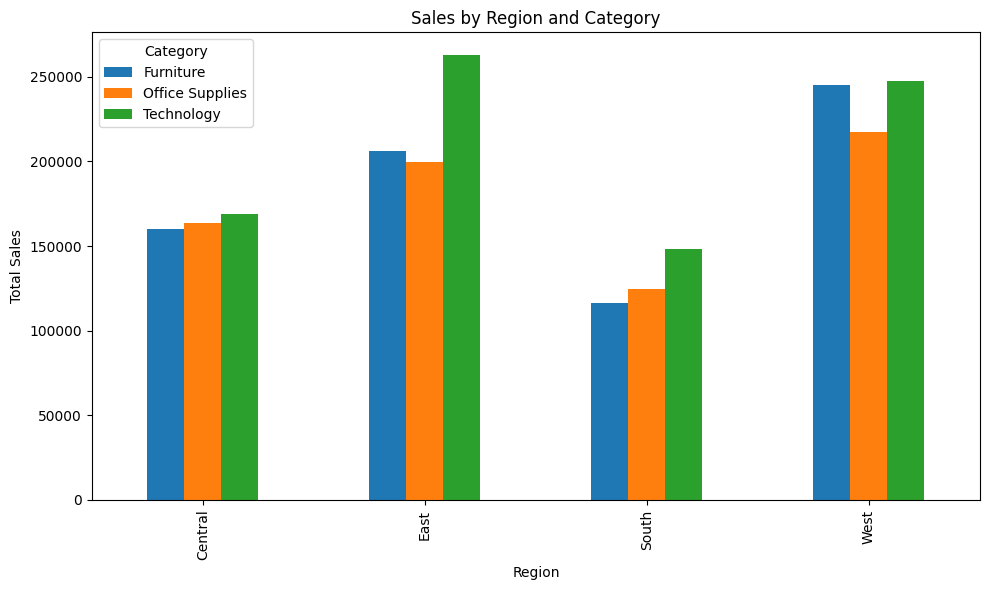

In [30]:
import matplotlib.pyplot as plt

pivot = region_category.pivot(index='Region', columns='Category', values='Sales')
pivot.plot(kind='bar', figsize=(10,6), title='Sales by Region and Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()